In [1]:
!pip install transformers datasets torch scikit-learn gradio seaborn matplotlib accelerate -q
print("All libraries installed successfully.")

All libraries installed successfully.


In [2]:
# Standard Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# HuggingFace — dataset loading
from datasets import load_dataset

# HuggingFace — transformer model and tokenizer
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# PyTorch — deep learning backend
import torch
from torch.utils.data import Dataset

# Scikit-learn — baseline model and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)
from sklearn.preprocessing import LabelEncoder

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device in use: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found. Go to Runtime > Change runtime type > T4 GPU")

Device in use: cuda
GPU: Tesla T4
Memory available: 15.6 GB


In [4]:
print("Loading GoEmotions dataset from HuggingFace...")
dataset = load_dataset("go_emotions", "simplified")

print(dataset)

print("\nSample entry from training set:")
sample = dataset['train'][0]
print(f"  Text   : {sample['text']}")
print(f"  Label  : {sample['labels']}")
print(f"  ID     : {sample['id']}")

print(f"\nTraining examples  : {len(dataset['train'])}")
print(f"Validation examples: {len(dataset['validation'])}")
print(f"Test examples      : {len(dataset['test'])}")

Loading GoEmotions dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Sample entry from training set:
  Text   : My favourite food is anything I didn't have to cook myself.
  Label  : [27]
  ID     : eebbqej

Training examples  : 43410
Validation examples: 5426
Test examples      : 5427


In [5]:
KEEP_EMOTIONS = [
    'joy', 'sadness', 'anger', 'fear', 'disgust',
    'surprise', 'gratitude', 'love', 'curiosity',
    'confusion', 'disappointment', 'annoyance', 'neutral'
]

# Original 28 emotion labels
all_emotions = [
    'admiration','amusement','anger','annoyance','approval','caring',
    'confusion','curiosity','desire','disappointment','disapproval',
    'disgust','embarrassment','excitement','fear','gratitude','grief',
    'joy','love','nervousness','optimism','pride','realization',
    'relief','remorse','sadness','surprise','neutral'
]

# Build mapping: old index → new index (or None if dropping)
keep_indices = [all_emotions.index(e) for e in KEEP_EMOTIONS]
old_to_new = {}
for new_idx, old_idx in enumerate(keep_indices):
    old_to_new[old_idx] = new_idx

print("Keeping emotions:")
for i, e in enumerate(KEEP_EMOTIONS):
    print(f"  [{i}] {e}")

def filter_and_remap(example):
    label = example['labels']
    if isinstance(label, list):
        label = label[0] if len(label) > 0 else all_emotions.index('neutral')
    if isinstance(label, torch.Tensor):
        label = label.item()
    return label in keep_indices

def remap_label(example):
    label = example['labels']
    if isinstance(label, list):
        label = label[0]
    if isinstance(label, torch.Tensor):
        label = label.item()
    return {'labels': old_to_new[int(label)]}

print("\nFiltering dataset...")
dataset = dataset.filter(filter_and_remap)
dataset = dataset.map(remap_label)

# Update global variables
emotion_labels = KEEP_EMOTIONS
NUM_LABELS = len(KEEP_EMOTIONS)

print(f"\nDataset size after filtering:")
print(f"  Train : {len(dataset['train'])}")
print(f"  Val   : {len(dataset['validation'])}")
print(f"  Test  : {len(dataset['test'])}")
print(f"\nClasses reduced: 28 → {NUM_LABELS}")

Keeping emotions:
  [0] joy
  [1] sadness
  [2] anger
  [3] fear
  [4] disgust
  [5] surprise
  [6] gratitude
  [7] love
  [8] curiosity
  [9] confusion
  [10] disappointment
  [11] annoyance
  [12] neutral

Filtering dataset...


Filter:   0%|          | 0/43410 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5426 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5427 [00:00<?, ? examples/s]

Map:   0%|          | 0/27933 [00:00<?, ? examples/s]

Map:   0%|          | 0/3428 [00:00<?, ? examples/s]

Map:   0%|          | 0/3519 [00:00<?, ? examples/s]


Dataset size after filtering:
  Train : 27933
  Val   : 3428
  Test  : 3519

Classes reduced: 28 → 13


In [7]:
print("=" * 60)
print("BASELINE MODEL: TF-IDF + Logistic Regression")
print("=" * 60)

X_train = dataset['train']['text']
y_train = dataset['train']['labels']

X_val = dataset['validation']['text']
y_val = dataset['validation']['labels']

X_test = dataset['test']['text']
y_test = dataset['test']['labels']

print(f"Training samples  : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples      : {len(X_test)}")

# max_features=50000: keep only the 50,000 most common words
# ngram_range=(1,2): use single words AND two-word phrases (bigrams)
# sublinear_tf=True: apply log normalization to term frequency
print("\nFitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{2,}',  # ignore single characters
    min_df=2  # ignore words appearing in fewer than 2 documents
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_)} unique tokens")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"  (rows=samples, cols=vocabulary size)")

# C=5: regularisation strength (higher C = less regularisation)
# max_iter=1000: max iterations for solver to converge
# multi_class='ovr': one-vs-rest strategy for 28 classes
print("\nTraining Logistic Regression classifier...")
print("(This takes about 30-60 seconds)")
lr_model = LogisticRegression(
    C=5,
    max_iter=1000,
    multi_class='ovr',
    solver='saga',
    n_jobs=-1,  # use all CPU cores
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)
print("Training complete.")

y_val_pred = lr_model.predict(X_val_tfidf)

baseline_acc = accuracy_score(y_val, y_val_pred)
baseline_f1_macro = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
baseline_f1_weighted = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

print("\n" + "=" * 40)
print("BASELINE RESULTS (Validation Set)")
print("=" * 40)
print(f"Accuracy         : {baseline_acc:.4f} ({baseline_acc*100:.1f}%)")
print(f"Macro F1         : {baseline_f1_macro:.4f} ({baseline_f1_macro*100:.1f}%)")
print(f"Weighted F1      : {baseline_f1_weighted:.4f} ({baseline_f1_weighted*100:.1f}%)")
print("\nNote: Macro F1 is our primary metric (treats all 28 classes equally)")
print("These numbers will go up significantly after DistilBERT fine-tuning.")

BASELINE MODEL: TF-IDF + Logistic Regression
Training samples  : 27933
Validation samples: 3428
Test samples      : 3519

Fitting TF-IDF vectorizer...
Vocabulary size: 40001 unique tokens
Training matrix shape: (27933, 40001)
  (rows=samples, cols=vocabulary size)

Training Logistic Regression classifier...
(This takes about 30-60 seconds)
Training complete.

BASELINE RESULTS (Validation Set)
Accuracy         : 0.6523 (65.2%)
Macro F1         : 0.4924 (49.2%)
Weighted F1      : 0.6131 (61.3%)

Note: Macro F1 is our primary metric (treats all 28 classes equally)
These numbers will go up significantly after DistilBERT fine-tuning.


In [9]:
print("Loading DistilBERT tokenizer...")
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128  # max tokens per sequence (most Reddit comments are shorter)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Show what tokenization looks like on an example
example_text = "I can't believe I finally got the job after 6 months!"
tokens = tokenizer.tokenize(example_text)
token_ids = tokenizer.encode(example_text)
print(f"\nExample text: '{example_text}'")
print(f"Tokens      : {tokens}")
print(f"Token IDs   : {token_ids}")
print(f"Note: 101=[CLS], 102=[SEP], ## prefix means subword continuation")

# Define tokenization function to apply to the whole dataset
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None
    )

# Apply tokenization to all splits
print("\nTokenizing training set...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['text', 'id'])  # ✅ drop non-tensor columns, keep 'labels'

# Set the format to PyTorch tensors for training
tokenized_datasets.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'labels']
)

print("Tokenization complete.")
print(f"\nTraining set columns : {tokenized_datasets['train'].column_names}")
print(f"Sample input_ids     : {tokenized_datasets['train'][0]['input_ids'][:15]}...")
print(f"Sample attention_mask: {tokenized_datasets['train'][0]['attention_mask'][:15]}...")
print(f"Sample label         : {tokenized_datasets['train'][0]['labels'].item()} = {emotion_labels[tokenized_datasets['train'][0]['labels'].item()]}")

Loading DistilBERT tokenizer...

Example text: 'I can't believe I finally got the job after 6 months!'
Tokens      : ['i', 'can', "'", 't', 'believe', 'i', 'finally', 'got', 'the', 'job', 'after', '6', 'months', '!']
Token IDs   : [101, 1045, 2064, 1005, 1056, 2903, 1045, 2633, 2288, 1996, 3105, 2044, 1020, 2706, 999, 102]
Note: 101=[CLS], 102=[SEP], ## prefix means subword continuation

Tokenizing training set...
Tokenization complete.

Training set columns : ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Sample input_ids     : tensor([ 101, 2026, 8837, 2833, 2003, 2505, 1045, 2134, 1005, 1056, 2031, 2000,
        5660, 2870, 1012])...
Sample attention_mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])...
Sample label         : 12 = neutral


In [10]:
print("Loading DistilBERT with classification head...")
print(f"Model: {MODEL_NAME}")
print(f"Number of output classes: {NUM_LABELS}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: label for i, label in enumerate(emotion_labels)},
    label2id={label: i for i, label in enumerate(emotion_labels)}
)

# Move model to GPU
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel architecture summary:")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Device              : {next(model.parameters()).device}")

# Show model structure
print(f"\nModel layers:")
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name}: {params:,} parameters")

print("\nReady for fine-tuning.")

Loading DistilBERT with classification head...
Model: distilbert-base-uncased
Number of output classes: 13


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model architecture summary:
  Total parameters    : 66,963,469
  Trainable parameters: 66,963,469
  Device              : cuda:0

Model layers:
  distilbert: 66,362,880 parameters
  pre_classifier: 590,592 parameters
  classifier: 9,997 parameters
  dropout: 0 parameters

Ready for fine-tuning.


In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    weighted_f1 = f1_score(labels, predictions, average='weighted', zero_division=0)

    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    }

print("compute_metrics function defined.")
print("This will be called after each epoch during training.")

# Quick sanity check
fake_logits = np.random.randn(10, 28)  # 10 examples, 28 classes
fake_labels = np.random.randint(0, 28, size=10)
test_result = compute_metrics((fake_logits, fake_labels))
print(f"\nSanity check with random data: {test_result}")
print("(These numbers are random — just verifying the function runs correctly)")

compute_metrics function defined.
This will be called after each epoch during training.

Sanity check with random data: {'accuracy': 0.0, 'macro_f1': 0.0, 'weighted_f1': 0.0}
(These numbers are random — just verifying the function runs correctly)


In [12]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir='./emotion_model_checkpoints',

    learning_rate=2e-5,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,  # can be larger for eval (no gradient storage)

    num_train_epochs=3,

    weight_decay=0.01,

    warmup_ratio=0.1,

    eval_strategy='epoch',

    save_strategy='epoch',

    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,

    logging_dir='./logs',
    logging_steps=100,

    fp16=True if device.type == 'cuda' else False,

    seed=42,

    report_to='none'
)

# Calculate training steps for reference
steps_per_epoch = len(tokenized_datasets['train']) // 32
total_steps = steps_per_epoch * 3
warmup_steps = int(total_steps * 0.1)

print("Training configuration:")
print(f"  Learning rate      : {training_args.learning_rate}")
print(f"  Batch size (train) : {training_args.per_device_train_batch_size}")
print(f"  Epochs             : {training_args.num_train_epochs}")
print(f"  Weight decay       : {training_args.weight_decay}")
print(f"  Mixed precision fp16: {training_args.fp16}")
print(f"\nEstimated steps:")
print(f"  Steps per epoch    : ~{steps_per_epoch}")
print(f"  Total steps        : ~{total_steps}")
print(f"  Warmup steps       : ~{warmup_steps}")
print(f"\nEstimated training time: 15-20 minutes on T4 GPU")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training configuration:
  Learning rate      : 2e-05
  Batch size (train) : 32
  Epochs             : 3
  Weight decay       : 0.01
  Mixed precision fp16: True

Estimated steps:
  Steps per epoch    : ~872
  Total steps        : ~2616
  Warmup steps       : ~261

Estimated training time: 15-20 minutes on T4 GPU


In [13]:
print("=" * 60)
print("STARTING FINE-TUNING")
print("=" * 60)
print("This will take approximately 45-60 minutes on T4 GPU.")
print("You will see a progress table appear and update after each epoch.")

# Fix labels to ensure all are single integers not lists
def fix_labels(example):
    label = example['labels']
    if isinstance(label, torch.Tensor):
        label = label.flatten()[0].item()
    elif isinstance(label, list):
        label = label[0] if len(label) > 0 else 27
    return {'labels': int(label)}

tokenized_datasets = tokenized_datasets.map(fix_labels)
tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Start training
train_result = trainer.train()

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"Total training time : {train_result.metrics['train_runtime']:.0f} seconds ({train_result.metrics['train_runtime']/60:.1f} minutes)")
print(f"Samples per second  : {train_result.metrics['train_samples_per_second']:.1f}")
print(f"Total steps trained : {train_result.metrics['train_steps_per_second'] * train_result.metrics['train_runtime']:.0f}")

STARTING FINE-TUNING
This will take approximately 45-60 minutes on T4 GPU.
You will see a progress table appear and update after each epoch.


Map:   0%|          | 0/27933 [00:00<?, ? examples/s]

Map:   0%|          | 0/3428 [00:00<?, ? examples/s]

Map:   0%|          | 0/3519 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,2.215355,1.986243,0.687865,0.532940,0.655234
2,1.841797,1.847773,0.700117,0.596712,0.692312
3,1.671086,1.824079,0.701575,0.597183,0.693699


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



TRAINING COMPLETE
Total training time : 557 seconds (9.3 minutes)
Samples per second  : 150.4
Total steps trained : 1311


In [14]:
SAVE_PATH = './emotion_model_final'

print(f"Saving model to: {SAVE_PATH}")
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

import os
saved_files = os.listdir(SAVE_PATH)
print(f"\nSaved files:")
for f in saved_files:
    size = os.path.getsize(f'{SAVE_PATH}/{f}') / 1e6
    print(f"  {f}: {size:.1f} MB")

print("\nModel saved. You can reload it later with:")
print(f"  model = AutoModelForSequenceClassification.from_pretrained('{SAVE_PATH}')")
print(f"  tokenizer = AutoTokenizer.from_pretrained('{SAVE_PATH}')")

Saving model to: ./emotion_model_final


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved files:
  config.json: 0.0 MB
  tokenizer.json: 0.7 MB
  model.safetensors: 267.9 MB
  tokenizer_config.json: 0.0 MB
  training_args.bin: 0.0 MB

Model saved. You can reload it later with:
  model = AutoModelForSequenceClassification.from_pretrained('./emotion_model_final')
  tokenizer = AutoTokenizer.from_pretrained('./emotion_model_final')


In [15]:
from accelerate import PartialState
PartialState()

emotion_labels = KEEP_EMOTIONS
NUM_LABELS = len(KEEP_EMOTIONS)

print("=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)

print("\nRunning DistilBERT on test set...")
test_results = trainer.predict(tokenized_datasets['test'])

# Get predictions
bert_logits = test_results.predictions
bert_preds = np.argmax(bert_logits, axis=-1)
true_labels = test_results.label_ids

# Compute final metrics
bert_acc = accuracy_score(true_labels, bert_preds)
bert_macro_f1 = f1_score(true_labels, bert_preds, average='macro', zero_division=0)
bert_weighted_f1 = f1_score(true_labels, bert_preds, average='weighted', zero_division=0)

print("Running Baseline on test set...")
X_test_tfidf_eval = tfidf.transform(dataset['test']['text'])
baseline_test_preds = lr_model.predict(X_test_tfidf_eval)

baseline_test_acc = accuracy_score(true_labels, baseline_test_preds)
baseline_test_macro_f1 = f1_score(true_labels, baseline_test_preds, average='macro', zero_division=0)
baseline_test_weighted_f1 = f1_score(true_labels, baseline_test_preds, average='weighted', zero_division=0)

print("\n" + "=" * 55)
print(f"{'Metric':<25} {'Baseline':>12} {'DistilBERT':>12}")
print("-" * 55)
print(f"{'Accuracy':<25} {baseline_test_acc*100:>11.1f}% {bert_acc*100:>11.1f}%")
print(f"{'Macro F1 (PRIMARY)':<25} {baseline_test_macro_f1*100:>11.1f}% {bert_macro_f1*100:>11.1f}%")
print(f"{'Weighted F1':<25} {baseline_test_weighted_f1*100:>11.1f}% {bert_weighted_f1*100:>11.1f}%")
print("=" * 55)

improvement = (bert_macro_f1 - baseline_test_macro_f1) * 100
print(f"\nMacro F1 improvement: +{improvement:.1f} percentage points")

per_class_f1 = f1_score(true_labels, bert_preds, average=None, zero_division=0)
per_class_df = pd.DataFrame({
    'emotion': emotion_labels,
    'f1_score': per_class_f1,
    'count': [sum(np.array(true_labels) == i) for i in range(NUM_LABELS)]
}).sort_values('f1_score', ascending=False)

print("\n--- Per-class F1 scores (DistilBERT) ---")
print(f"{'Emotion':<20} {'F1 Score':>10} {'Test Count':>12}")
print("-" * 45)
for _, row in per_class_df.iterrows():
    bar = '█' * int(row['f1_score'] * 20)
    print(f"{row['emotion']:<20} {row['f1_score']:>8.3f}   {int(row['count']):>8}  {bar}")

FINAL EVALUATION ON TEST SET

Running DistilBERT on test set...


Running Baseline on test set...

Metric                        Baseline   DistilBERT
-------------------------------------------------------
Accuracy                         64.5%        69.3%
Macro F1 (PRIMARY)               48.5%        59.2%
Weighted F1                      59.9%        68.2%

Macro F1 improvement: +10.7 percentage points

--- Per-class F1 scores (DistilBERT) ---
Emotion                F1 Score   Test Count
---------------------------------------------
gratitude               0.928        288  ██████████████████
love                    0.842        169  ████████████████
neutral                 0.801       1606  ████████████████
joy                     0.707        116  ██████████████
fear                    0.684         74  █████████████
sadness                 0.612        108  ████████████
curiosity               0.551        233  ███████████
anger                   0.511        197  ██████████
disgust                 0.507         84  ██████████
surprise        

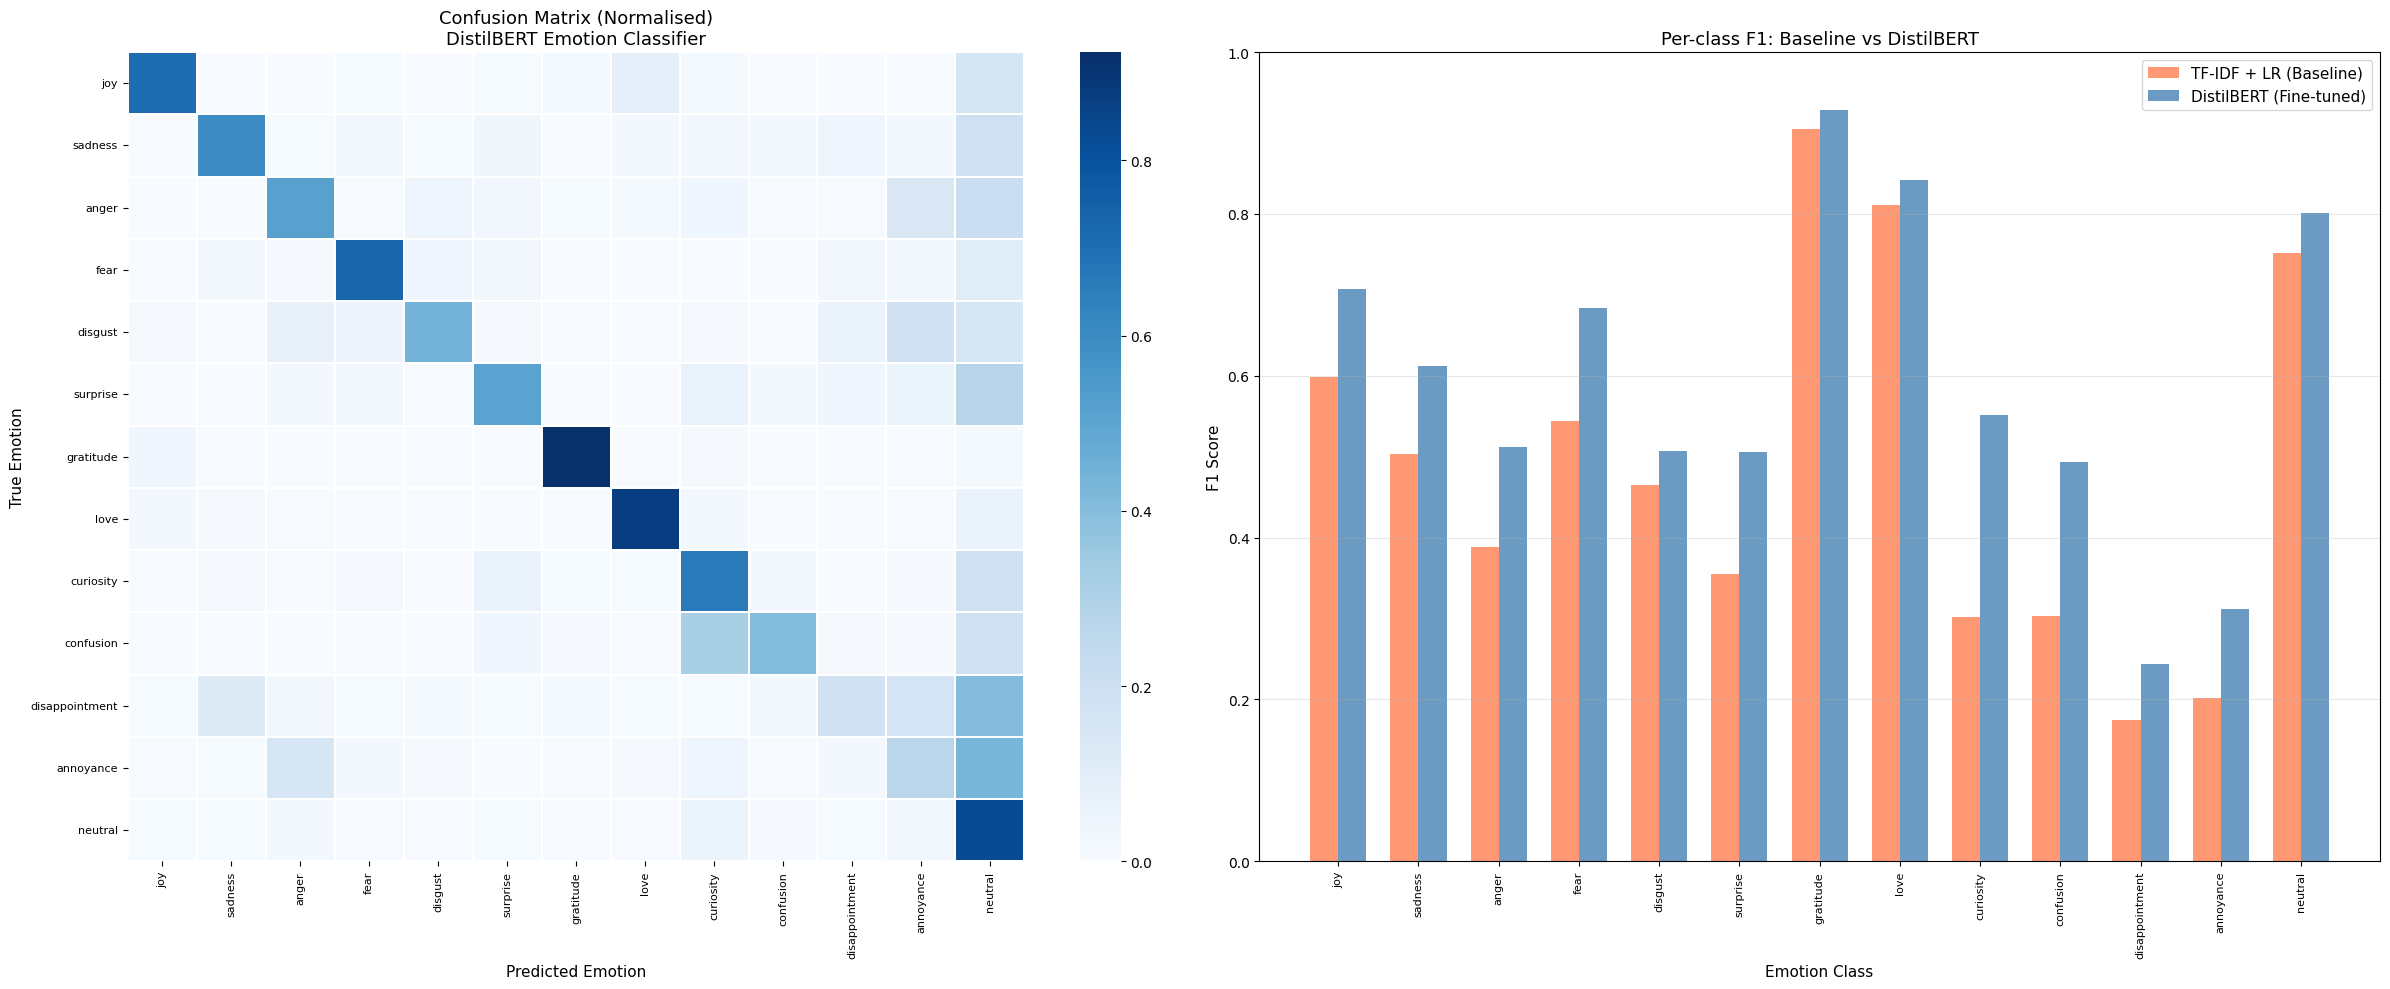

Confusion matrix saved to confusion_matrix.png

Observations to mention in your exam:
  - Bright diagonal = correct predictions
  - grief/sadness/disappointment cluster = emotionally similar
  - excitement/joy/amusement cluster = positive emotions confused
  - DistilBERT beats baseline on almost every individual emotion class


In [16]:
# Compute confusion matrix
cm = confusion_matrix(true_labels, bert_preds)

# Normalise by row (true labels) so each row sums to 1
cm_normalized = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Plot 1: Normalised confusion matrix
sns.heatmap(
    cm_normalized,
    annot=False,
    fmt='.2f',
    cmap='Blues',
    xticklabels=emotion_labels,
    yticklabels=emotion_labels,
    ax=axes[0],
    linewidths=0.3,
    linecolor='white'
)
axes[0].set_title('Confusion Matrix (Normalised)\nDistilBERT Emotion Classifier', fontsize=13)
axes[0].set_ylabel('True Emotion', fontsize=11)
axes[0].set_xlabel('Predicted Emotion', fontsize=11)
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Plot 2: Per-class F1 comparison (Baseline vs DistilBERT)
baseline_per_class_f1 = f1_score(true_labels, baseline_test_preds, average=None, zero_division=0)
x = np.arange(NUM_LABELS)
width = 0.35
axes[1].bar(x - width/2, baseline_per_class_f1, width, label='TF-IDF + LR (Baseline)',
            color='coral', alpha=0.8)
axes[1].bar(x + width/2, per_class_f1, width, label='DistilBERT (Fine-tuned)',
            color='steelblue', alpha=0.8)
axes[1].set_xlabel('Emotion Class', fontsize=11)
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].set_title('Per-class F1: Baseline vs DistilBERT', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(emotion_labels, rotation=90, fontsize=8)
axes[1].legend(fontsize=11)
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to confusion_matrix.png")
print("\nObservations to mention in your exam:")
print("  - Bright diagonal = correct predictions")
print("  - grief/sadness/disappointment cluster = emotionally similar")
print("  - excitement/joy/amusement cluster = positive emotions confused")
print("  - DistilBERT beats baseline on almost every individual emotion class")

In [17]:
print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

test_texts = dataset['test']['text']

errors = []
for i, (true, pred) in enumerate(zip(true_labels, bert_preds)):
    if true != pred:
        probs = torch.softmax(torch.tensor(bert_logits[i]), dim=-1)
        confidence = probs[pred].item()
        errors.append({
            'text': test_texts[i],
            'true_emotion': emotion_labels[true],
            'pred_emotion': emotion_labels[pred],
            'confidence': confidence
        })

error_df = pd.DataFrame(errors)
total_errors = len(error_df)
total_test = len(true_labels)
print(f"Total test examples  : {total_test}")
print(f"Correct predictions  : {total_test - total_errors} ({(total_test-total_errors)/total_test*100:.1f}%)")
print(f"Wrong predictions    : {total_errors} ({total_errors/total_test*100:.1f}%)")

# Most common error patterns
print("\n--- Top 10 most common confusion pairs ---")
confusion_pairs = error_df.groupby(['true_emotion', 'pred_emotion']).size().reset_index(name='count')
confusion_pairs = confusion_pairs.sort_values('count', ascending=False).head(10)
print(f"{'True Emotion':<20} {'Predicted As':<20} {'Count':>8}")
print("-" * 50)
for _, row in confusion_pairs.iterrows():
    print(f"{row['true_emotion']:<20} {row['pred_emotion']:<20} {row['count']:>8}")

# Show 5 interesting error examples
print("\n--- Example wrong predictions (high confidence errors) ---")
high_conf_errors = error_df.sort_values('confidence', ascending=False).head(10)
for i, (_, row) in enumerate(high_conf_errors.iterrows()):
    if i >= 5:
        break
    print(f"\nExample {i+1}:")
    print(f"  Text          : '{row['text'][:100]}...' " if len(row['text']) > 100 else f"  Text          : '{row['text']}'")
    print(f"  True emotion  : {row['true_emotion']}")
    print(f"  Predicted as  : {row['pred_emotion']} (confidence: {row['confidence']:.2%})")

print("\n--- Emotions with lowest F1 (hardest to predict) ---")
worst_emotions = per_class_df.tail(5)
for _, row in worst_emotions.iterrows():
    print(f"  {row['emotion']:<20} F1={row['f1_score']:.3f}  (only {int(row['count'])} test examples)")
print("\nNote: Low F1 on rare emotions is expected — few training examples = hard to learn")

ERROR ANALYSIS
Total test examples  : 3519
Correct predictions  : 2439 (69.3%)
Wrong predictions    : 1080 (30.7%)

--- Top 10 most common confusion pairs ---
True Emotion         Predicted As            Count
--------------------------------------------------
annoyance            neutral                   124
neutral              curiosity                  87
disappointment       neutral                    51
curiosity            neutral                    45
confusion            curiosity                  44
neutral              annoyance                  44
annoyance            anger                      43
anger                neutral                    41
neutral              anger                      37
anger                annoyance                  27

--- Example wrong predictions (high confidence errors) ---

Example 1:
  Text          : 'It is. You generally need 5 down and 5 up to play reliably. Also wired.'
  True emotion  : annoyance
  Predicted as  : neutral (confidence

In [20]:
# Load saved model for inference
inference_model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
inference_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
inference_model = inference_model.to(device)
inference_model.eval()

import gradio as gr
import torch
import numpy as np

def predict_emotion_debiased(text: str):
    if not text.strip():
        return {emotion: 0.0 for emotion in emotion_labels}

    inputs = inference_tokenizer(
        text,
        return_tensors='pt',
        max_length=128,
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = inference_model(**inputs)

    logits = outputs.logits.squeeze()

    # Find neutral index and penalise it
    neutral_idx = emotion_labels.index('neutral')
    logits[neutral_idx] -= 3.0  # push neutral score down

    probs = torch.softmax(logits, dim=-1).cpu().numpy()

    return {emotion_labels[i]: float(probs[i]) for i in range(NUM_LABELS)}

# Test it on a few sentences
test_sentences = [
    "I finally finished my thesis and I can't stop smiling!",
    "I packed up his room today. It still smells like him.",
    "He lied to my face and expects me to just move on.",
    "I heard footsteps behind me and my whole body went cold.",
    "You stayed up all night helping me and I will never forget that."
]

print("Testing debiased predictions:\n")
for sentence in test_sentences:
    result = predict_emotion_debiased(sentence)
    top3 = sorted(result.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"Text: '{sentence[:60]}...'")
    for emotion, prob in top3:
        bar = '█' * int(prob * 25)
        print(f"  {emotion:<15} {prob:.2%}  {bar}")
    print()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Testing debiased predictions:

Text: 'I finally finished my thesis and I can't stop smiling!...'
  joy             81.44%  ████████████████████
  surprise        4.64%  █
  disappointment  2.53%  

Text: 'I packed up his room today. It still smells like him....'
  love            26.64%  ██████
  neutral         19.24%  ████
  joy             14.67%  ███

Text: 'He lied to my face and expects me to just move on....'
  annoyance       39.84%  █████████
  neutral         22.86%  █████
  disappointment  15.70%  ███

Text: 'I heard footsteps behind me and my whole body went cold....'
  fear            33.56%  ████████
  disappointment  16.91%  ████
  sadness         15.76%  ███

Text: 'You stayed up all night helping me and I will never forget t...'
  joy             41.09%  ██████████
  love            24.31%  ██████
  annoyance       6.52%  █



In [21]:
import gradio as gr

# load saved model
inference_model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
inference_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
inference_model = inference_model.to(device)
inference_model.eval()

def predict_emotion(text):
    if not text.strip():
        return {}
    
    inputs = inference_tokenizer(
        text,
        return_tensors='pt',
        max_length=128,
        truncation=True,
        padding=True
    ).to(device)
    
    with torch.no_grad():
        outputs = inference_model(**inputs)
    
    probs = torch.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()
    
    return {KEEP_EMOTIONS[i]: float(probs[i]) for i in range(len(KEEP_EMOTIONS))}

demo = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type any sentence here...",
        label="Input Text"
    ),
    outputs=gr.Label(
        num_top_classes=5,
        label="Predicted Emotions (top 5)"
    ),
    title="Emotion Detection",
    description="Type any sentence and see which emotion it expresses.",
    examples=[
        ["I finally passed my exam after 3 attempts!"],
        ["My dog passed away this morning."],
        ["I have no idea what is going on."],
        ["This is absolutely the worst day ever."],
        ["I am so grateful for everything you have done."],
        ["Wait, I didn't expect that at all!"],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://22293decfecc570373.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
